# 🧪 A/B Test Analysis: E-commerce Landing Page

## ❓Business question

We use the A/B Testing Dataset, which tracks 30 days of a paid marketing experiment with two variants (Control and Test) across the funnel: spend, impressions, clicks, add-to-cart, and purchases.

Each row represents one campaign-day, not individual users.

Helper functions and setup are in the collapsed cells below.

## 🧮 Data overview

About Dataset
A/B testing helps in finding a better approach to finding customers, marketing products, getting a higher reach, or anything that helps a business convert most of its target customers into actual customers.

**Below are all the features in the dataset:**

- Campaign Name: The name of the campaign
- Date: Date of the record
- Spend: Amount spent on the campaign in dollars of Impressions: Number of impressions the ad crossed through the campaign
- Reach: The number of unique impressions received in the adof Website Clicks:
- Number of website clicks received through the adsof Searches:
- Number of users who performed searches on the website of View Content:
- Number of users who viewed content and products on the website of Add to Cart:
- Number of users who added products to the cart of Purchase: Number of purchases

Two campaigns were performed by the company:
- Control Campaign
- Test Campaign

In [1]:
# upload libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro
from warnings import simplefilter
simplefilter("ignore")

In [2]:
# upload data
path = "./"
control = pd.read_csv(path + "control_group.csv", sep=";")
test = pd.read_csv(path + "test_group.csv", sep=";")


# add group column and combine
control['group'] = 'control'
test['group'] = 'treatment'
df = pd.concat([control, test], ignore_index=True)

In [3]:
df.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase,group
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,control


In [4]:
# overview shapes
print(control.shape)
print(test.shape)

(30, 11)
(30, 11)


## ☝️ Data quality checks

In [5]:
df.columns

Index(['Campaign Name', 'Date', 'Spend [USD]', '# of Impressions', 'Reach',
       '# of Website Clicks', '# of Searches', '# of View Content',
       '# of Add to Cart', '# of Purchase', 'group'],
      dtype='str')

In [6]:
# Clean version: lowercase + replace "# of " → "n_"
df.columns = (
    df.columns
    .str.lower()
    .str.replace(r"#\s*of\s*", "n_", regex=True)
    .str.replace(r"\s*\[.*?\]", "", regex=True)  # Remove [USD]
    .str.replace(r"\s+", "_", regex=True)
    .str.strip()
)

df.columns

Index(['campaign_name', 'date', 'spend', 'n_impressions', 'reach',
       'n_website_clicks', 'n_searches', 'n_view_content', 'n_add_to_cart',
       'n_purchase', 'group'],
      dtype='str')

In [7]:
# Check null values
print("Null values per column:")
print(df.isnull().sum())

print("\nNull values %:")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\nDataset shape:", df.shape)

Null values per column:
campaign_name       0
date                0
spend               0
n_impressions       1
reach               1
n_website_clicks    1
n_searches          1
n_view_content      1
n_add_to_cart       1
n_purchase          1
group               0
dtype: int64

Null values %:
campaign_name       0.00
date                0.00
spend               0.00
n_impressions       1.67
reach               1.67
n_website_clicks    1.67
n_searches          1.67
n_view_content      1.67
n_add_to_cart       1.67
n_purchase          1.67
group               0.00
dtype: float64

Dataset shape: (60, 11)


In [8]:
# Check zero values per column
print("Zero values per column:")
zeros_count = (df == 0).sum()
print(zeros_count)

print("\nZero values %:")
zeros_pct = ((df == 0).sum() / len(df) * 100).round(2)
print(zeros_pct)

print("\nTotal zero rows:")
print((df == 0).any(axis=1).sum())

Zero values per column:
campaign_name       0
date                0
spend               0
n_impressions       0
reach               0
n_website_clicks    0
n_searches          0
n_view_content      0
n_add_to_cart       0
n_purchase          0
group               0
dtype: int64

Zero values %:
campaign_name       0.0
date                0.0
spend               0.0
n_impressions       0.0
reach               0.0
n_website_clicks    0.0
n_searches          0.0
n_view_content      0.0
n_add_to_cart       0.0
n_purchase          0.0
group               0.0
dtype: float64

Total zero rows:
0


In [9]:
# Zero impressions days by group
zero_imp_days = df[df['n_impressions'] == 0].groupby('group')['date'].nunique()
print("Zero impressions days:")
print(zero_imp_days)

# Check if other metrics also zero (expected)
zero_imp_rows = df[df['n_impressions'] == 0][
    ['date', 'group', 'n_impressions', 'n_website_clicks', 'n_purchase', 'spend']
]
print("\nZero impressions rows:")
print(zero_imp_rows.head())

Zero impressions days:
Series([], Name: date, dtype: int64)

Zero impressions rows:
Empty DataFrame
Columns: [date, group, n_impressions, n_website_clicks, n_purchase, spend]
Index: []


**in Control group we have a day with spend > 0 and 0 metrics, just keep it in mind now**

## 🧐 Exploratory analysis

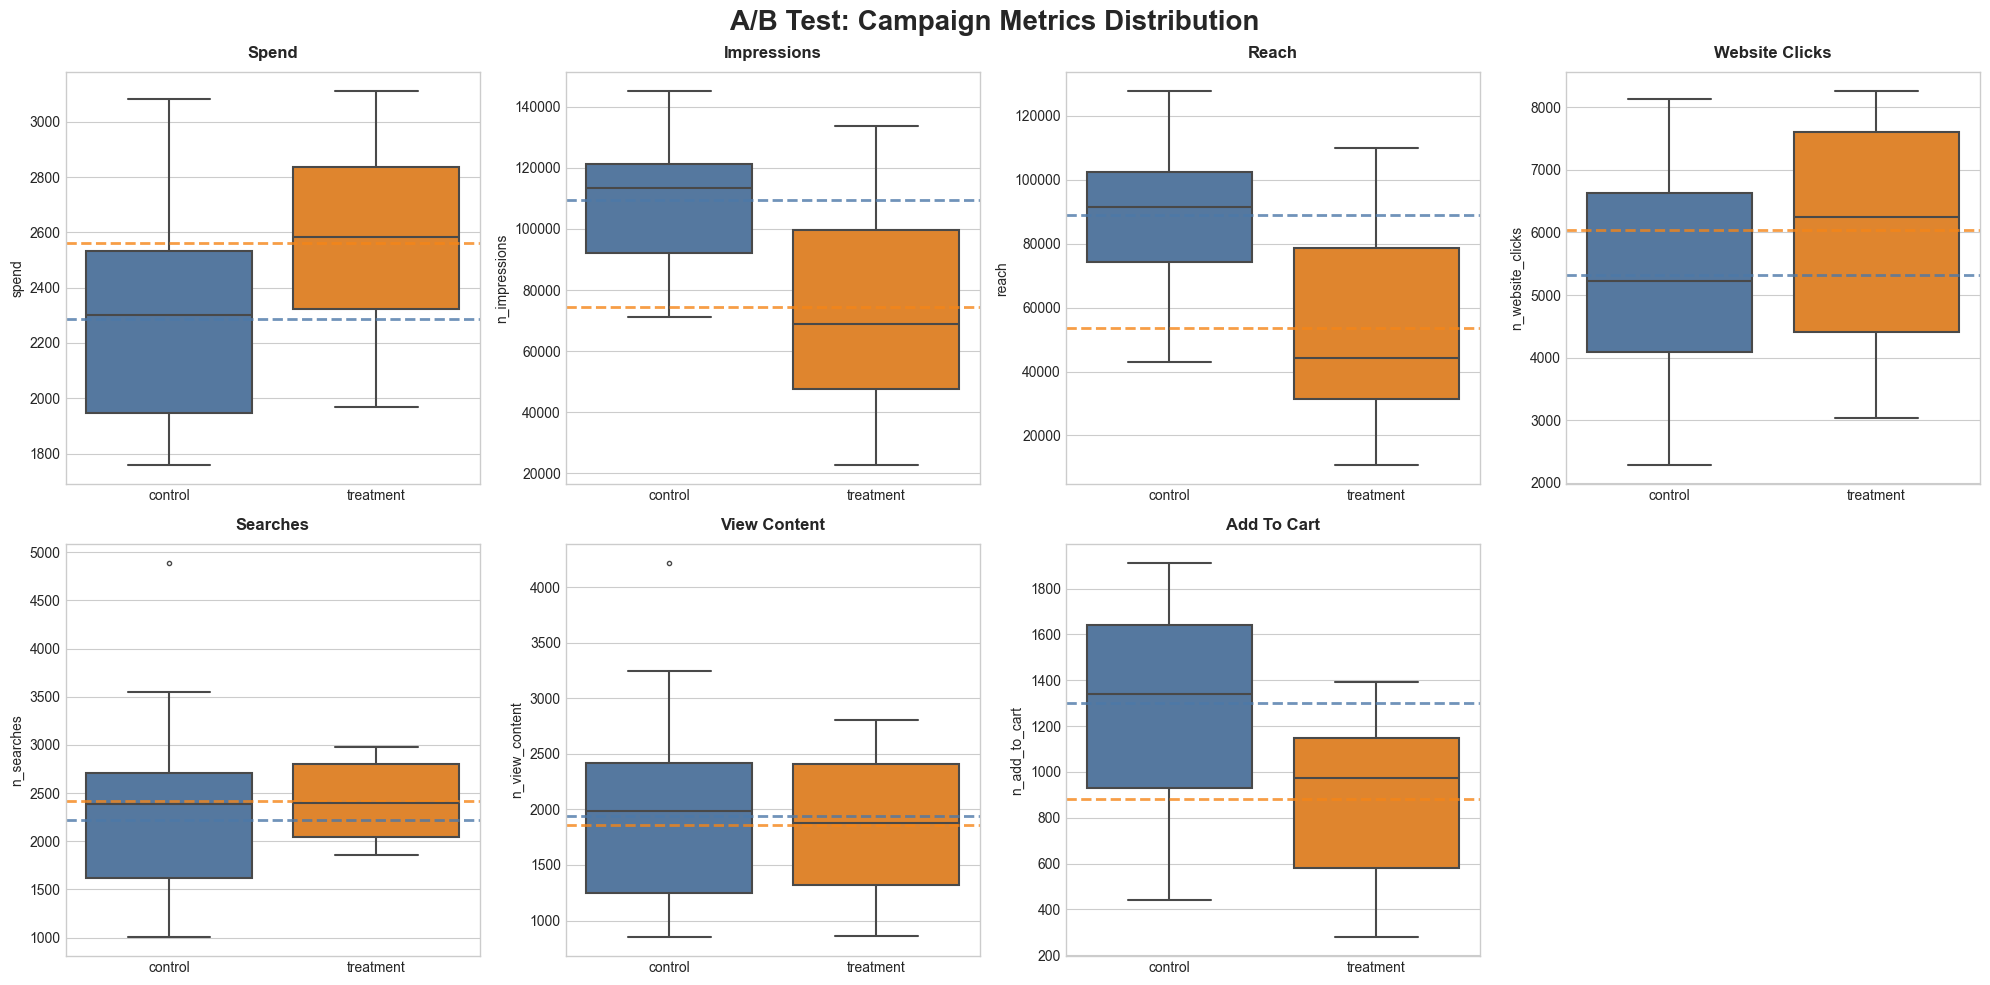

In [10]:
# metrics
metrics = ['spend', 'n_impressions', 'reach', 'n_website_clicks', 
           'n_searches', 'n_view_content', 'n_add_to_cart', 'n_purchase']

# Awesome styling
plt.style.use('seaborn-v0_8-whitegrid')
colors = ['#4C78A8', '#F58518']  # control, test

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    sns.boxplot(
        data=df, x='group', y=metric,
        palette=colors, ax=axes[i], saturation=0.8,
        linewidth=1.5, fliersize=3
    )
    
    # Clean titles
    metric_name = metric.replace('n_', '').replace('_', ' ').title()
    axes[i].set_title(metric_name, fontweight='bold', pad=10)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', labelsize=10)
    
    # Add mean line
    means = df.groupby('group')[metric].mean()
    for j, group in enumerate(['control', 'treatment']):
        axes[i].axhline(means[group], color=colors[j], linestyle='--', 
                       linewidth=2, alpha=0.8, label=f'{group} mean')

axes[-1].set_visible(False)  # Hide empty subplot
plt.suptitle('A/B Test: Campaign Metrics Distribution', fontsize=20, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

In [11]:

# Add marketing metrics
df['conversion_rate'] = df['n_purchase'] / df['n_website_clicks']
df['cost_per_click'] = df['spend'] / df['n_website_clicks']
df['cost_per_purchase'] = df['spend'] / df['n_purchase']
df['click_through_rate'] = df['n_website_clicks'] / df['n_impressions']

# Handle divide by zero (inf → NaN → 0)
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df[['conversion_rate', 'cost_per_click', 'cost_per_purchase', 'click_through_rate']] = df[
    ['conversion_rate', 'cost_per_click', 'cost_per_purchase', 'click_through_rate']
].fillna(0)

# Preview
df[['group', 'n_impressions', 'n_website_clicks', 'n_purchase', 'spend',
    'conversion_rate', 'click_through_rate', 'cost_per_click', 'cost_per_purchase']].head()

,group,n_impressions,n_website_clicks,n_purchase,spend,conversion_rate,click_through_rate,cost_per_click,cost_per_purchase
0,control,82702.0,7016.0,618.0,2280,0.088084,0.084835,0.324971,3.689320
1,control,121040.0,8110.0,511.0,1757,0.063009,0.067003,0.216646,3.438356
2,control,131711.0,6508.0,372.0,2343,0.057160,0.049411,0.360018,6.298387
3,control,72878.0,3065.0,340.0,1940,0.110930,0.042057,0.632953,5.705882
4,control,NaN,NaN,NaN,1835,0.000000,0.000000,0.000000,0.000000


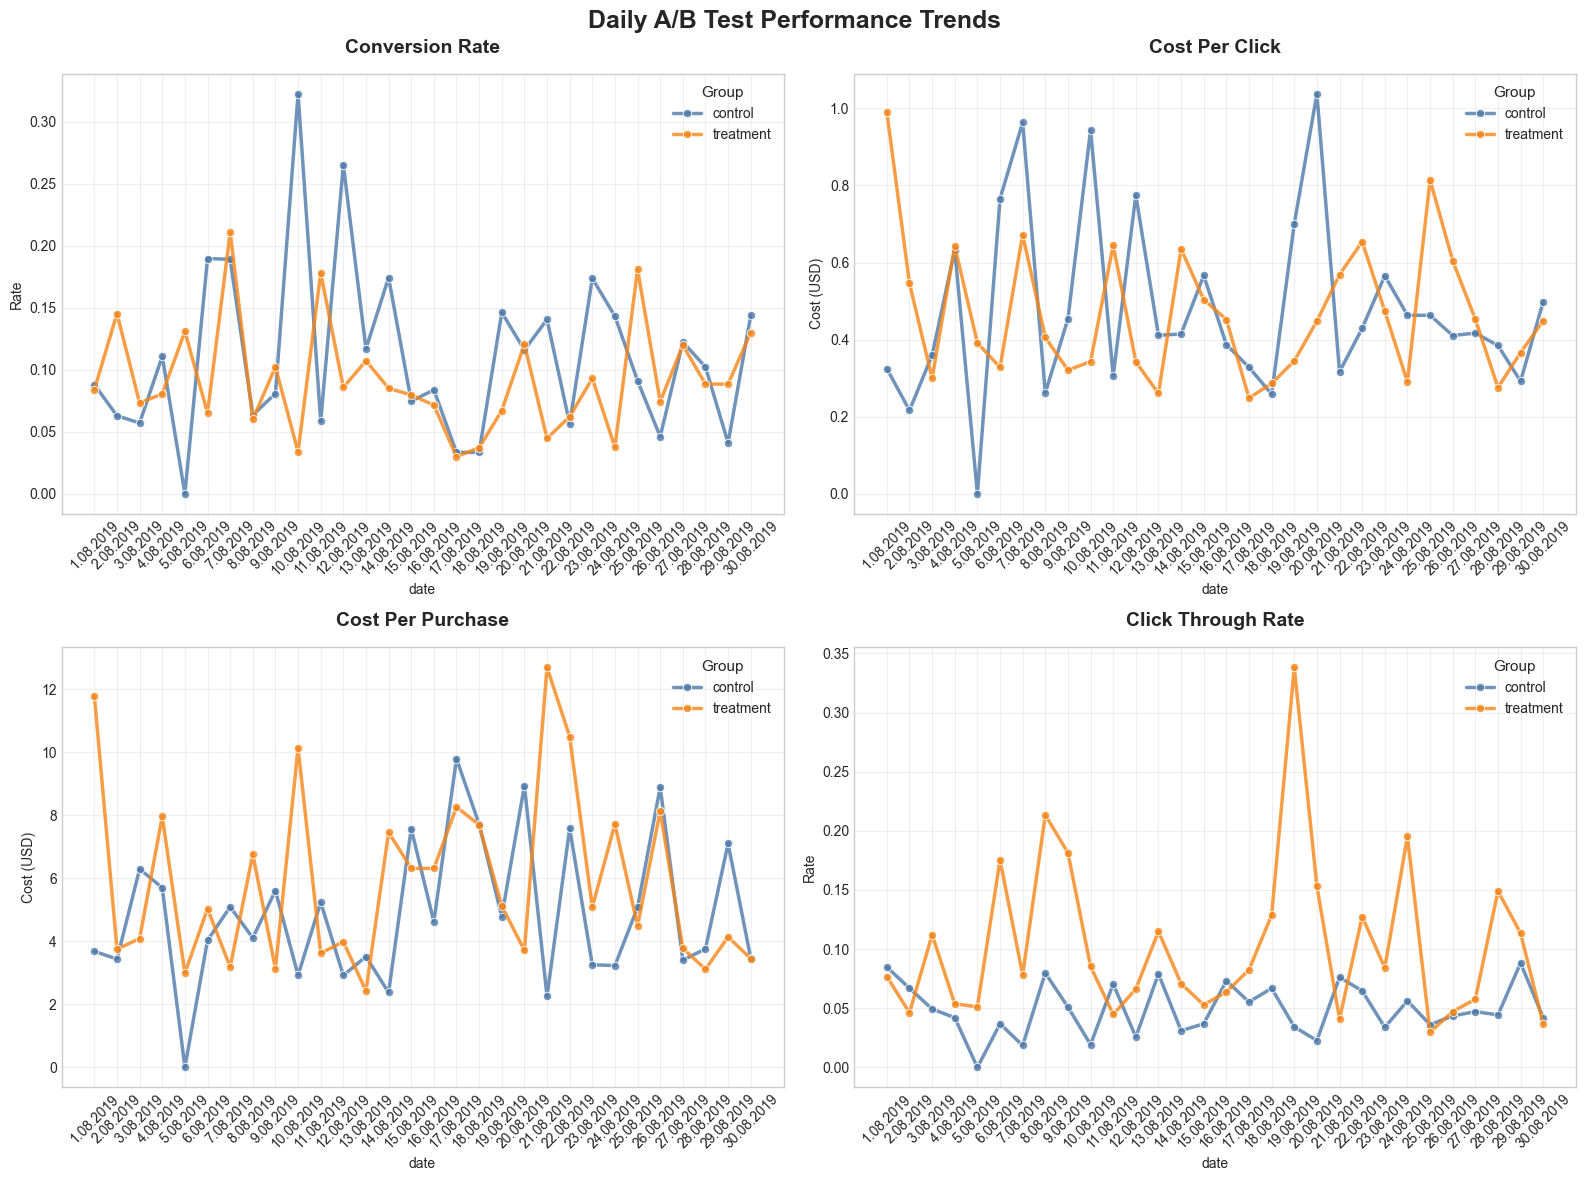

In [12]:
# Your time-series metrics
metrics_time = ['conversion_rate', 'cost_per_click', 'cost_per_purchase', 'click_through_rate']

# Awesome time series grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

colors = ['#4C78A8', '#F58518']  # control, test

for i, metric in enumerate(metrics_time):
    sns.lineplot(
        data=df, x='date', y=metric, hue='group',
        palette=colors, ax=axes[i], linewidth=2.5, alpha=0.8,
        marker='o', markersize=6
    )
    
    # Styling
    axes[i].set_title(metric.replace('_', ' ').title(), fontweight='bold', pad=15, fontsize=14)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend(title='Group', title_fontsize=11, fontsize=10)
    
    # Y-axis formatting
    if 'rate' in metric:
        axes[i].set_ylabel('Rate')
    elif 'cost' in metric:
        axes[i].set_ylabel('Cost (USD)')

plt.suptitle('Daily A/B Test Performance Trends', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

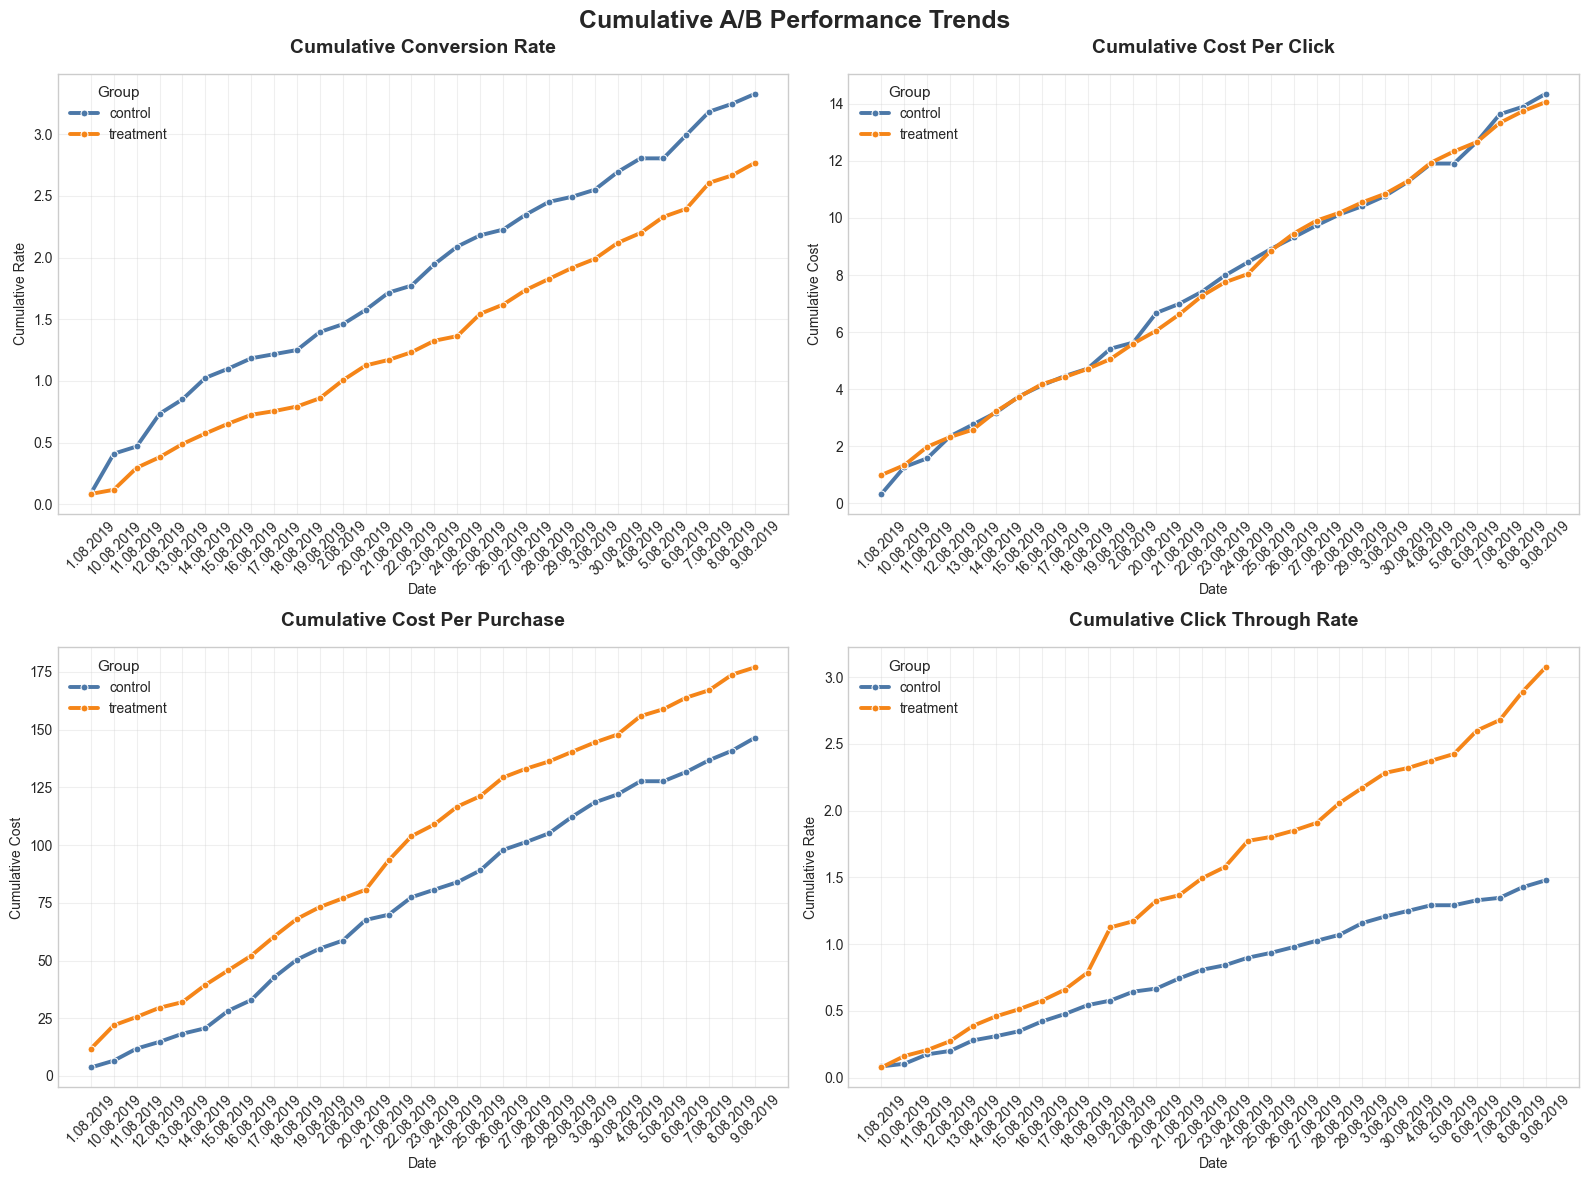

In [13]:
metrics_time = ['conversion_rate', 'cost_per_click', 'cost_per_purchase', 'click_through_rate']

df_sorted = df.sort_values('date').copy()

for metric in metrics_time:
    df_sorted[f'cum_{metric}'] = df_sorted.groupby('group')[metric].cumsum()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

palette = {'control': '#4C78A8', 'treatment': '#F58518'}

for i, metric in enumerate(metrics_time):
    ax = axes[i]
    
    sns.lineplot(
        data=df_sorted,
        x='date',
        y=f'cum_{metric}',
        hue='group',
        palette=palette,
        ax=ax,
        linewidth=2.8,
        marker='o',
        markersize=5
    )
    
    ax.set_title(f'Cumulative {metric.replace("_", " ").title()}', fontweight='bold', pad=15, fontsize=14)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3)
    ax.set_xlabel('Date')
    
    if 'rate' in metric:
        ax.set_ylabel('Cumulative Rate')
    else:
        ax.set_ylabel('Cumulative Cost')
    
    ax.legend(title='Group', fontsize=10, title_fontsize=11)

plt.suptitle('Cumulative A/B Performance Trends', fontsize=18, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

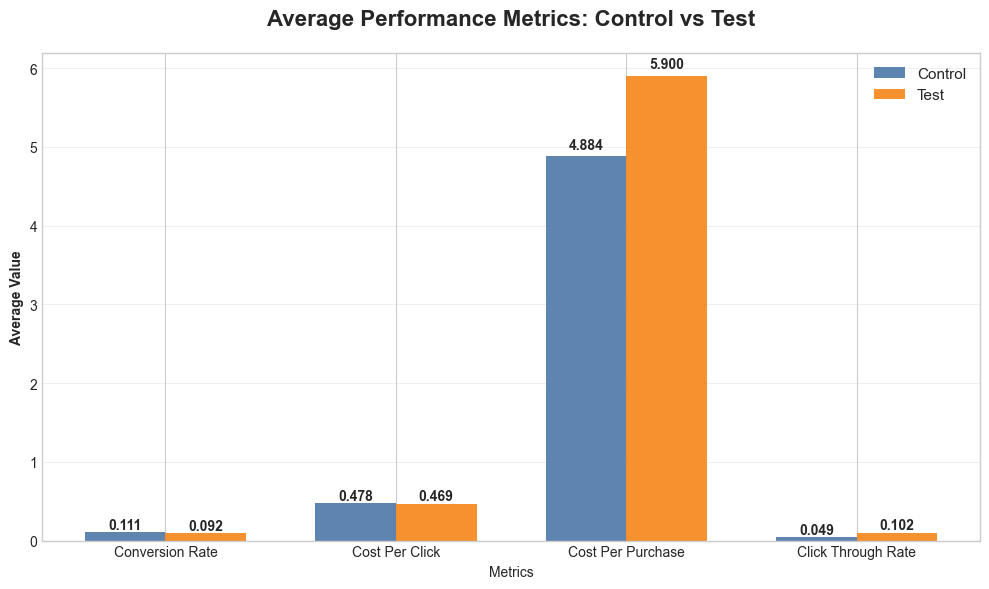

In [14]:
# Average metrics comparison (grouped bar chart)
avg_metrics = df.groupby('group')[metrics_time].mean()

fig, ax = plt.subplots(figsize=(10, 6))

# Grouped bars
width = 0.35
x = np.arange(len(metrics_time))

bars1 = ax.bar(x - width/2, avg_metrics.loc['control'], width, 
               label='Control', color='#4C78A8', alpha=0.9)
bars2 = ax.bar(x + width/2, avg_metrics.loc['treatment'], width, 
               label='Test', color='#F58518', alpha=0.9)

# Styling
ax.set_title('Average Performance Metrics: Control vs Test', fontweight='bold', pad=20, fontsize=16)
ax.set_ylabel('Average Value', fontweight='bold')
ax.set_xlabel('Metrics')
ax.set_xticks(x)
ax.set_xticklabels([m.replace('_', ' ').title() for m in metrics_time], rotation=0)

# Value labels on bars
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + height*0.01,
            f'{height:.3f}', ha='center', va='bottom', fontweight='bold')

ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 🧹 Experiment validation

SHAPIRO-WILK TEST FOR NORMALITY
Null Hypothesis: Data is normally distributed
If p-value < 0.05: REJECT null hypothesis (data is NOT normal)
If p-value >= 0.05: FAIL to reject (data appears normal)

CONVERSION_RATE
--------------------------------------------------------------------------------
  control      | Statistic: 0.9220 | p-value: 0.030287 | ✗ NOT NORMAL
  treatment    | Statistic: 0.9255 | p-value: 0.037268 | ✗ NOT NORMAL

COST_PER_CLICK
--------------------------------------------------------------------------------
  control      | Statistic: 0.9230 | p-value: 0.032196 | ✗ NOT NORMAL
  treatment    | Statistic: 0.9114 | p-value: 0.016188 | ✗ NOT NORMAL

COST_PER_PURCHASE
--------------------------------------------------------------------------------
  control      | Statistic: 0.9527 | p-value: 0.199778 | ✓ NORMAL
  treatment    | Statistic: 0.8966 | p-value: 0.006934 | ✗ NOT NORMAL

CLICK_THROUGH_RATE
-----------------------------------------------------------------------

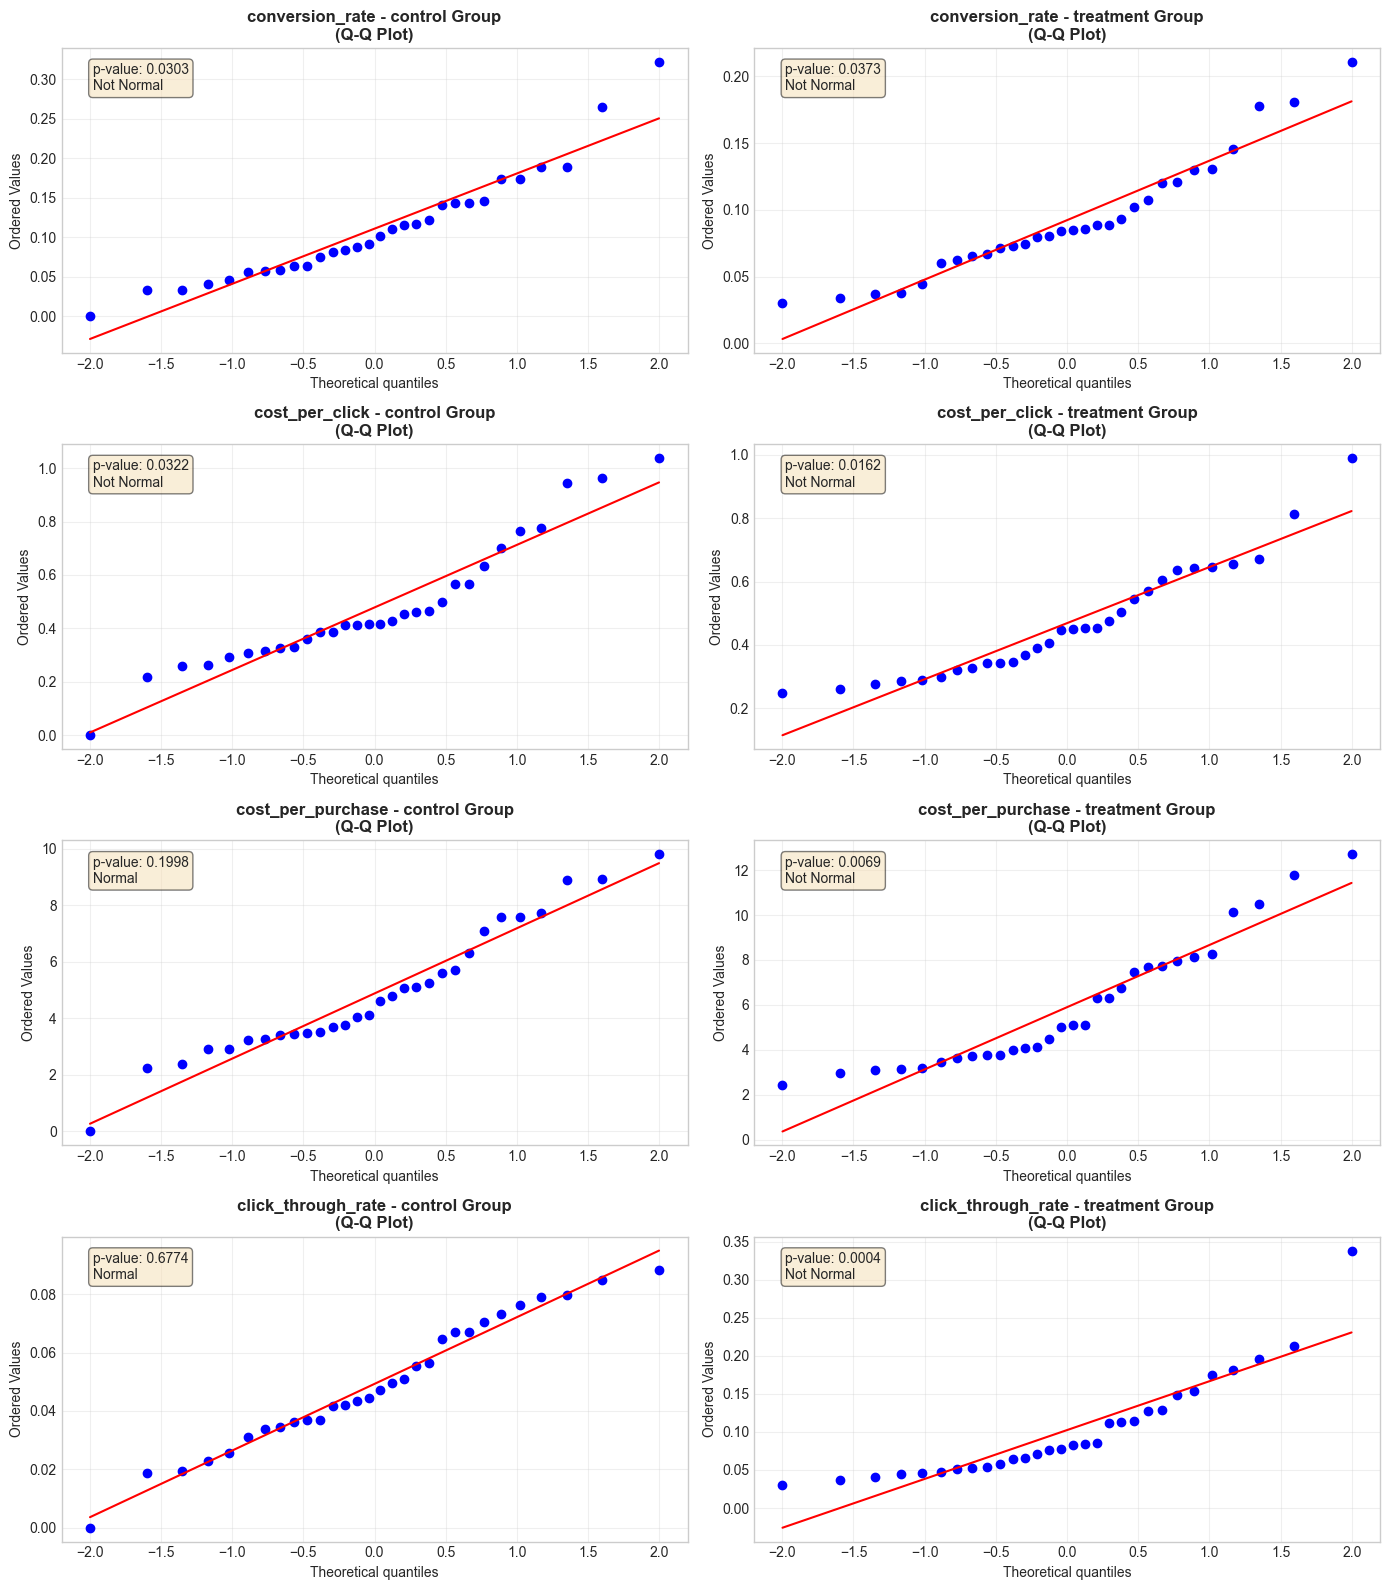


SUMMARY TABLE - NORMALITY TEST RESULTS
            Metric     Group Shapiro-Wilk Stat  p-value Normal?
   conversion_rate   control            0.9220 0.030287    No ✗
   conversion_rate treatment            0.9255 0.037268    No ✗
    cost_per_click   control            0.9230 0.032196    No ✗
    cost_per_click treatment            0.9114 0.016188    No ✗
 cost_per_purchase   control            0.9527 0.199778   Yes ✓
 cost_per_purchase treatment            0.8966 0.006934    No ✗
click_through_rate   control            0.9748 0.677430   Yes ✓
click_through_rate treatment            0.8409 0.000403    No ✗

RECOMMENDATIONS FOR HYPOTHESIS TESTING

CONVERSION_RATE:
  ✗ At least one group is NOT normal → Use: Mann-Whitney U test
    (or apply log-transformation and retest)

COST_PER_CLICK:
  ✗ At least one group is NOT normal → Use: Mann-Whitney U test
    (or apply log-transformation and retest)

COST_PER_PURCHASE:
  ✗ At least one group is NOT normal → Use: Mann-Whitney U test
    (or

In [15]:
# Metrics to check
metrics = ['conversion_rate', 'cost_per_click', 'cost_per_purchase', 'click_through_rate']

# ============================================================================
# 1. SHAPIRO-WILK TEST FOR NORMALITY
# ============================================================================
print("=" * 80)
print("SHAPIRO-WILK TEST FOR NORMALITY")
print("=" * 80)
print("Null Hypothesis: Data is normally distributed")
print("If p-value < 0.05: REJECT null hypothesis (data is NOT normal)")
print("If p-value >= 0.05: FAIL to reject (data appears normal)")
print("=" * 80)

results_shapiro = {}

for metric in metrics:
    print(f"\n{metric.upper()}")
    print("-" * 80)
    
    for group in df['group'].unique():
        data = df[df['group'] == group][metric].values
        stat, p_value = stats.shapiro(data)
        
        results_shapiro[f"{metric}_{group}"] = {
            'statistic': stat,
            'p_value': p_value,
            'is_normal': p_value >= 0.05
        }
        
        status = "✓ NORMAL" if p_value >= 0.05 else "✗ NOT NORMAL"
        print(f"  {group:12} | Statistic: {stat:.4f} | p-value: {p_value:.6f} | {status}")

# ============================================================================
# 2. Q-Q PLOTS
# ============================================================================
print("\n" + "=" * 80)
print("GENERATING Q-Q PLOTS")
print("=" * 80)
print("Interpretation: Points close to the diagonal line indicate normal distribution")
print("=" * 80)

fig, axes = plt.subplots(len(metrics), 2, figsize=(14, 4 * len(metrics)))

for idx, metric in enumerate(metrics):
    for group_idx, group in enumerate(sorted(df['group'].unique())):
        data = df[df['group'] == group][metric].values
        
        ax = axes[idx, group_idx] if len(metrics) > 1 else axes[group_idx]
        
        # Q-Q plot
        stats.probplot(data, dist="norm", plot=ax)
        ax.set_title(f"{metric} - {group} Group\n(Q-Q Plot)", fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add p-value from Shapiro-Wilk test to the plot
        key = f"{metric}_{group}"
        p_val = results_shapiro[key]['p_value']
        status = "Normal" if p_val >= 0.05 else "Not Normal"
        ax.text(0.05, 0.95, f"p-value: {p_val:.4f}\n{status}", 
                transform=ax.transAxes, fontsize=10,
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
print("✓ Q-Q plots saved as 'qq_plots.png'")
plt.show()

# ============================================================================
# 3. SUMMARY TABLE
# ============================================================================
print("\n" + "=" * 80)
print("SUMMARY TABLE - NORMALITY TEST RESULTS")
print("=" * 80)

summary_data = []
for metric in metrics:
    for group in sorted(df['group'].unique()):
        key = f"{metric}_{group}"
        result = results_shapiro[key]
        summary_data.append({
            'Metric': metric,
            'Group': group,
            'Shapiro-Wilk Stat': f"{result['statistic']:.4f}",
            'p-value': f"{result['p_value']:.6f}",
            'Normal?': "Yes ✓" if result['is_normal'] else "No ✗"
        })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))

# ============================================================================
# 4. RECOMMENDATIONS
# ============================================================================
print("\n" + "=" * 80)
print("RECOMMENDATIONS FOR HYPOTHESIS TESTING")
print("=" * 80)

for metric in metrics:
    control_normal = results_shapiro[f"{metric}_control"]['is_normal']
    treatment_normal = results_shapiro[f"{metric}_treatment"]['is_normal']
    
    print(f"\n{metric.upper()}:")
    if control_normal and treatment_normal:
        print(f"  ✓ Both groups are NORMAL → Use: Independent t-test (or Welch's t-test)")
    else:
        print(f"  ✗ At least one group is NOT normal → Use: Mann-Whitney U test")
        print(f"    (or apply log-transformation and retest)")

print("\n" + "=" * 80)

## 📐 Applying Stat Methods and Measure effect

In [22]:
metrics = ['conversion_rate', 'cost_per_click', 'cost_per_purchase', 'click_through_rate']

# ============================================================================
# HELPER FUNCTIONS
# ============================================================================

def calculate_effect_size_rank_biserial(n1, n2, U):
    """Calculate rank-biserial correlation for Mann-Whitney U test"""
    return 1 - (2 * U) / (n1 * n2)

def interpret_rank_biserial(r):
    """Interpret rank-biserial correlation effect size"""
    r_abs = abs(r)
    if r_abs < 0.1:
        return "negligible"
    elif r_abs < 0.3:
        return "small"
    elif r_abs < 0.5:
        return "medium"
    else:
        return "large"

def interpret_p_value(p_val, alpha=0.05):
    """Interpret p-value"""
    return "Significant ✓" if p_val < alpha else "Not Significant ✗"

# ============================================================================
# APPLY MANN-WHITNEY U TESTS TO DATAFRAME
# ============================================================================

print("\n" + "=" * 100)
print("MANN-WHITNEY U TEST RESULTS")
print("=" * 100)

# Store results
test_results = []

for metric in metrics:
    # Split data by group
    control_data = df[df['group'] == 'control'][metric].values
    treatment_data = df[df['group'] == 'treatment'][metric].values
    
    print(f"\n{'=' * 100}")
    print(f"METRIC: {metric.upper()}")
    print(f"{'=' * 100}")
    
    # Descriptive Statistics
    print(f"\nDESCRIPTIVE STATISTICS:")
    print(f"  Control Group:")
    print(f"    Count: {len(control_data)}")
    print(f"    Mean: {control_data.mean():.6f}")
    print(f"    Median: {np.median(control_data):.6f}")
    print(f"    Std Dev: {control_data.std():.6f}")
    print(f"    Min/Max: [{control_data.min():.6f}, {control_data.max():.6f}]")
    
    print(f"\n  Treatment Group:")
    print(f"    Count: {len(treatment_data)}")
    print(f"    Mean: {treatment_data.mean():.6f}")
    print(f"    Median: {np.median(treatment_data):.6f}")
    print(f"    Std Dev: {treatment_data.std():.6f}")
    print(f"    Min/Max: [{treatment_data.min():.6f}, {treatment_data.max():.6f}]")
    
    median_diff = np.median(treatment_data) - np.median(control_data)
    print(f"\n  Median Difference (Treatment - Control): {median_diff:.6f}")
    
    # =====================================================================
    # MANN-WHITNEY U TEST
    # =====================================================================
    
    U_stat, p_value = stats.mannwhitneyu(treatment_data, control_data, alternative='two-sided')
    
    # Effect Size
    r_rb = calculate_effect_size_rank_biserial(len(treatment_data), len(control_data), U_stat)
    effect_interp = interpret_rank_biserial(r_rb)
    
    # Interpretation
    sig_result = interpret_p_value(p_value)
    
    print(f"\nMANN-WHITNEY U TEST:")
    print(f"  U-statistic: {U_stat:.4f}")
    print(f"  p-value: {p_value:.6f}")
    print(f"  Result: {sig_result}")
    print(f"  Effect Size (rank-biserial r): {r_rb:.4f} ({effect_interp})")
    
    # Store results
    test_results.append({
        'Metric': metric,
        'Control_Count': len(control_data),
        'Control_Mean': control_data.mean(),
        'Control_Median': np.median(control_data),
        'Control_Std': control_data.std(),
        'Treatment_Count': len(treatment_data),
        'Treatment_Mean': treatment_data.mean(),
        'Treatment_Median': np.median(treatment_data),
        'Treatment_Std': treatment_data.std(),
        'Median_Difference': median_diff,
        'U_Statistic': U_stat,
        'p_value': p_value,
        'Significant': 'Yes' if p_value < 0.05 else 'No',
        'Effect_Size': r_rb,
        'Effect_Interpretation': effect_interp
    })

# ============================================================================
# RESULTS DATAFRAME
# ============================================================================

results_df = pd.DataFrame(test_results)

print("\n\n" + "=" * 100)
print("SUMMARY TABLE - ALL MANN-WHITNEY U TEST RESULTS")
print("=" * 100)

# Display key columns
display_cols = ['Metric', 'Control_Median', 'Treatment_Median', 'Median_Difference', 
                'p_value', 'Significant', 'Effect_Size', 'Effect_Interpretation']
print("\n" + results_df[display_cols].to_string(index=False))



MANN-WHITNEY U TEST RESULTS - APPLIED TO YOUR DATAFRAME

METRIC: CONVERSION_RATE

DESCRIPTIVE STATISTICS:
  Control Group:
    Count: 30
    Mean: 0.110946
    Median: 0.096721
    Std Dev: 0.069202
    Min/Max: [0.000000, 0.322354]

  Treatment Group:
    Count: 30
    Mean: 0.092312
    Median: 0.084543
    Std Dev: 0.043742
    Min/Max: [0.030088, 0.210851]

  Median Difference (Treatment - Control): -0.012178

MANN-WHITNEY U TEST:
  U-statistic: 397.0000
  p-value: 0.437641
  Result: Not Significant ✗
  Effect Size (rank-biserial r): 0.1178 (small)

METRIC: COST_PER_CLICK

DESCRIPTIVE STATISTICS:
  Control Group:
    Count: 30
    Mean: 0.478411
    Median: 0.415927
    Std Dev: 0.231265
    Min/Max: [0.000000, 1.037626]

  Treatment Group:
    Count: 30
    Mean: 0.468718
    Median: 0.448842
    Std Dev: 0.175565
    Min/Max: [0.248799, 0.990125]

  Median Difference (Treatment - Control): 0.032916

MANN-WHITNEY U TEST:
  U-statistic: 450.0000
  p-value: 1.000000
  Result: Not S